In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Choosing beta for the f-beta score :

For betting purposes, precision is more important than recall. For a precision of 1 and a recall of 0.7, we choose a beta coefficient such that f-beta is close to 0.95.


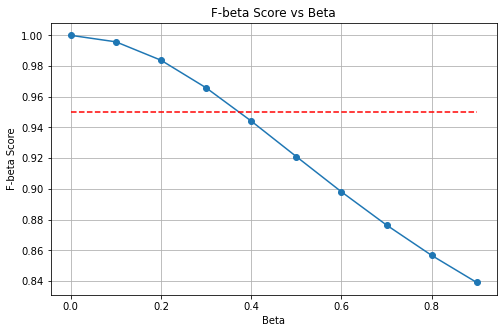

In [4]:
prec = 1.0
rec = 0.7

beta = np.arange(0, 1.0, 0.1)
fbeta_scores = [(1 + bet**2) * (prec * rec) / (bet**2 * prec + rec) for bet in beta]

plt.figure(figsize=(8, 5))
plt.plot(beta, fbeta_scores, marker='o')
plt.plot(beta, [0.95]*len(beta), linestyle='--', color='red')
plt.xlabel('Beta')
plt.ylabel('F-beta Score')
plt.title('F-beta Score vs Beta')
plt.grid(True)
plt.show()

beta = 0.4 seems to be a good choice

### Features dataset exploration

In [16]:
df = pd.read_csv("../data/processed/clean_features_dataset.csv")
print(df.columns)

Index(['h_a', 'minutes_since_last_goal_before_match', 'reliability_score',
       'delay_score', 'time_last_3_matches', 'goals_last_3_matches',
       'xG_last_3_matches', 'total_team_matches_before_match',
       'team_pts_before_match', 'total_team_goals_scored_before_match',
       'total_team_xg_before_match', 'total_opponent_matches_before_match',
       'opponent_pts_before_match',
       'total_opponent_goals_conceded_before_match',
       'total_opponent_xga_before_match',
       'opponent_clean_sheet_rate_before_match', 'scored', 'starting',
       'league_Bundesliga', 'league_EPL', 'league_La_Liga', 'league_Ligue_1',
       'league_Serie_A', 'ratio_min_goals_last_3_matches',
       'ratio_min_xg_last_3_matches', 'ratio_pts_match',
       'ratio_pts_match_opponent', 'ratio_goals_scored', 'ratio_xG',
       'ratio_goals_conceded_opponent', 'ratio_xga_opponent'],
      dtype='object')


In [6]:
df.tail()

,h_a,minutes_since_last_goal_before_match,reliability_score,delay_score,time_last_3_matches,goals_last_3_matches,xG_last_3_matches,total_team_matches_before_match,team_pts_before_match,total_team_goals_scored_before_match,...,league_Ligue_1,league_Serie_A,ratio_min_goals_last_3_matches,ratio_min_xg_last_3_matches,ratio_pts_match,ratio_pts_match_opponent,ratio_goals_scored,ratio_xG,ratio_goals_conceded_opponent,ratio_xga_opponent
4474,0,10.0,0.525696,-1.007433,182.0,2.0,1.281226,30,54,54,...,0.0,0.0,91.0,142.051477,1.800000,1.366667,1.800000,1.902881,1.533333,1.459452
4475,1,28.0,0.525696,-0.877805,122.0,1.0,0.746225,31,55,56,...,0.0,0.0,122.0,163.489460,1.774194,1.064516,1.806452,1.897811,1.548387,1.470629
4476,0,118.0,0.525696,-0.229670,122.0,1.0,0.911514,32,55,57,...,0.0,0.0,122.0,133.843270,1.718750,1.500000,1.781250,1.881178,1.281250,1.492089
4477,1,203.0,0.525696,0.382458,193.0,0.0,0.382471,33,58,58,...,0.0,0.0,300.0,504.612823,1.757576,1.454545,1.757576,1.837386,1.333333,1.433835
4478,1,48.0,0.525696,-0.733775,265.0,1.0,1.087793,34,61,60,...,0.0,0.0,265.0,243.612418,1.794118,1.705882,1.764706,1.837714,1.294118,1.374426


In [7]:
# Distribution of the target variable 'scored'
print("Distribution of the target 'scored':")
print(df['scored'].value_counts())
print(f"   - Proportion: {df['scored'].mean():.3f}")

Distribution of the target 'scored':
0    2833
1    1646
Name: scored, dtype: int64
   - Proportion: 0.367


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4479 entries, 0 to 4478
Data columns (total 31 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   h_a                                         4479 non-null   int64  
 1   minutes_since_last_goal_before_match        4479 non-null   float64
 2   reliability_score                           4479 non-null   float64
 3   delay_score                                 4479 non-null   float64
 4   time_last_3_matches                         4479 non-null   float64
 5   goals_last_3_matches                        4479 non-null   float64
 6   xG_last_3_matches                           4479 non-null   float64
 7   total_team_matches_before_match             4479 non-null   int64  
 8   team_pts_before_match                       4479 non-null   int64  
 9   total_team_goals_scored_before_match        4479 non-null   int64  
 10  total_team_x

In [10]:
df.describe()

,h_a,minutes_since_last_goal_before_match,reliability_score,delay_score,time_last_3_matches,goals_last_3_matches,xG_last_3_matches,total_team_matches_before_match,team_pts_before_match,total_team_goals_scored_before_match,...,league_Ligue_1,league_Serie_A,ratio_min_goals_last_3_matches,ratio_min_xg_last_3_matches,ratio_pts_match,ratio_pts_match_opponent,ratio_goals_scored,ratio_xG,ratio_goals_conceded_opponent,ratio_xga_opponent
count,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,...,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000,4479.000000
mean,0.506810,152.401206,0.509824,-0.066580,215.605939,1.410583,1.366164,18.027908,32.216343,33.499219,...,0.088413,0.104711,189.265649,304.429819,1.763472,1.348424,1.839800,1.860451,1.396418,1.504793
std,0.500009,155.519856,0.172202,0.958941,60.915843,1.269417,0.959784,10.416210,20.806652,21.897258,...,0.283926,0.306215,92.811593,535.352499,0.633907,0.620374,0.721991,0.581117,0.536833,0.459051
min,0.000000,0.000000,0.123400,-1.529673,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,2.772415,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,40.000000,0.393688,-0.770003,182.000000,0.000000,0.630943,9.000000,15.000000,16.000000,...,0.000000,0.000000,99.000000,112.559074,1.366667,0.969223,1.388889,1.497460,1.076923,1.260446
50%,1.000000,105.000000,0.488965,-0.347934,241.000000,1.000000,1.172873,18.000000,30.000000,32.000000,...,0.000000,0.000000,193.000000,178.713512,1.785714,1.333333,1.823529,1.885278,1.380952,1.506991
75%,1.000000,212.000000,0.654478,0.368849,266.000000,2.000000,1.921091,27.000000,46.000000,49.000000,...,0.000000,0.000000,300.000000,308.612180,2.222222,1.733333,2.222222,2.219025,1.677419,1.771770
max,1.000000,1160.000000,0.906860,5.267940,270.000000,8.000000,6.356295,37.000000,94.000000,117.000000,...,1.000000,1.000000,300.000000,12647.282886,3.000000,3.000000,6.000000,4.679670,5.000000,3.986640


In [17]:
# Correlations with the target variable 'scored'
correlations = df.corr()['scored'].sort_values(ascending=False)
print("Correlations with 'scored':")
print(correlations.head(10))
print(correlations.tail())

Correlations with 'scored':
scored                           1.000000
starting                         0.169742
reliability_score                0.136806
ratio_xga_opponent               0.088428
xG_last_3_matches                0.088404
time_last_3_matches              0.080444
ratio_goals_conceded_opponent    0.068833
h_a                              0.060940
goals_last_3_matches             0.058806
league_Bundesliga                0.052834
Name: scored, dtype: float64
ratio_min_xg_last_3_matches              -0.033137
league_EPL                               -0.033183
opponent_pts_before_match                -0.035752
opponent_clean_sheet_rate_before_match   -0.056084
ratio_pts_match_opponent                 -0.058753
Name: scored, dtype: float64


#### Keeping only players with reliability_score >= 0.7

In [18]:
df = df[df['reliability_score'] >= 0.7]
print(f"Dataset size after filtering by reliability_score >= 0.7: {len(df)}")
df.head()

Dataset size after filtering by reliability_score >= 0.7: 723


,h_a,minutes_since_last_goal_before_match,reliability_score,delay_score,time_last_3_matches,goals_last_3_matches,xG_last_3_matches,total_team_matches_before_match,team_pts_before_match,total_team_goals_scored_before_match,...,league_Ligue_1,league_Serie_A,ratio_min_goals_last_3_matches,ratio_min_xg_last_3_matches,ratio_pts_match,ratio_pts_match_opponent,ratio_goals_scored,ratio_xG,ratio_goals_conceded_opponent,ratio_xga_opponent
0,0,20.0,0.717436,-0.859705,270.0,1.0,2.273906,3,7,6,...,0.0,0.0,270.000000,118.738413,2.333333,2.000000,2.000000,2.687160,1.000000,1.516238
1,1,5.0,0.717436,-0.997549,270.0,2.0,3.190067,4,10,8,...,0.0,0.0,135.000000,84.637723,2.500000,1.750000,2.000000,2.458508,1.250000,1.371385
2,1,59.0,0.717436,-0.501310,270.0,3.0,3.261110,5,13,13,...,0.0,0.0,90.000000,82.793885,2.600000,0.800000,2.600000,2.476062,1.400000,1.503289
3,0,6.0,0.717436,-0.988360,270.0,4.0,2.693737,6,16,16,...,0.0,0.0,67.500000,100.232517,2.666667,0.833333,2.666667,2.367128,1.666667,1.952122
4,1,31.0,0.717436,-0.758619,205.0,3.0,1.628961,7,17,18,...,0.0,0.0,68.333333,125.847123,2.428571,1.166667,2.571429,2.261560,1.500000,1.383665


In [13]:
# Distribution of the target variable 'scored'
print("Distribution of the target 'scored':")
print(df['scored'].value_counts())
print(f"   - Proportion: {df['scored'].mean():.3f}")

Distribution of the target 'scored':
0    368
1    355
Name: scored, dtype: int64
   - Proportion: 0.491


In [15]:
# Correlations with the target variable 'scored'
correlations = df.corr()['scored'].sort_values(ascending=False)
print("Correlations with 'scored':")
print(correlations.head(10))
print(correlations.tail())

Correlations with 'scored':
scored                           1.000000
starting                         0.186627
time_last_3_matches              0.158583
reliability_score                0.118609
ratio_xG                         0.114272
ratio_goals_scored               0.110302
ratio_goals_conceded_opponent    0.105106
ratio_xga_opponent               0.096742
xG_last_3_matches                0.092518
delay_score                      0.062982
Name: scored, dtype: float64
league_La_Liga                           -0.038412
league_EPL                               -0.045413
opponent_pts_before_match                -0.051021
ratio_pts_match_opponent                 -0.101068
opponent_clean_sheet_rate_before_match   -0.102414
Name: scored, dtype: float64


### Model evaluation results

This include only players with reliability_score >= REL_THR (config.py).

In [19]:
import json

filepath = "../data/dictionaries/model_evaluation_results.json"
with open(filepath, 'r') as f:
    results = json.load(f)

In [22]:
# Construction of DataFrames for metrics and threshold metrics
metrics_data = []
threshold_metrics_data = []

for model_name, model_data in results.items():
    metrics_data.append({
        'Model': model_name,
        'Accuracy': model_data['metrics']['accuracy'],
        'Precision': model_data['metrics']['precision'],
        'Recall': model_data['metrics']['recall'],
        'F-beta': model_data['metrics']['fbeta'],
    })
    
    threshold_metrics_data.append({
        'Model': model_name,
        'Best threshold': model_data['best_threshold'],
        'Accuracy (threshold)': model_data['threshold_metrics']['accuracy'],
        'Precision (threshold)': model_data['threshold_metrics']['precision'],
        'Recall (threshold)': model_data['threshold_metrics']['recall'],
        'F-beta (threshold)': model_data['threshold_metrics']['fbeta']
    })

df_metrics = pd.DataFrame(metrics_data)
df_threshold = pd.DataFrame(threshold_metrics_data)

In [25]:
print("="*60)
print("📊 MODELS COMPARISON - STANDARD THRESHOLD (0.5)")
print("="*60)
display(df_metrics.round(4))

📊 MODELS COMPARISON - STANDARD THRESHOLD (0.5)


,Model,Accuracy,Precision,Recall,F-beta
0,logistic_regression,0.6434,0.6145,0.7286,0.6225
1,random_forest,0.5944,0.5857,0.5857,0.5857
2,xgboost,0.6364,0.6250,0.6429,0.6264


Random forest is less efficient than logistic regression and xgboost.
Lr and xgboost have similar precision but the recall is much better for lr.

In [26]:
print("\n" + "="*60)
print("🎯 MODELS COMPARISON - WITH OPTIMAL THRESHOLD")
print("="*60)
display(df_threshold.round(4))


🎯 MODELS COMPARISON - WITH OPTIMAL THRESHOLD


,Model,Best threshold,Accuracy (threshold),Precision (threshold),Recall (threshold),F-beta (threshold)
0,logistic_regression,0.53,0.6573,0.6780,0.5714,0.6677
1,random_forest,0.45,0.6364,0.6000,0.7714,0.6112
2,xgboost,0.49,0.6434,0.6301,0.6571,0.6323


Logistic regression gives better results with a precision of 0.68.